For linear regression, our EDA needs to rigorously check the 4 key assumptions:

    Linearity (Are the relationships straight lines?)

    Homoscedasticity (Is the variance constant across levels?)

    Normality (Are the residuals normally distributed? We check the target first).

    No perfect multicollinearity (Are the features too correlated with each other?).

Let's dive into a comprehensive, excellence-driven EDA.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
#Step 1: Load & Initial Inspection
# Load data (no header, columns: Size, Bedrooms, Price)
df = pd.read_csv('data/ex1data2.txt', header=None, names=['Size', 'Bedrooms', 'Price'])

# Glimpse: Load & Initial Inspection
print(df.head())
print(df.info())
print(df.describe())

   Size  Bedrooms   Price
0  2104         3  399900
1  1600         3  329900
2  2400         3  369000
3  1416         2  232000
4  3000         4  539900
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Size      47 non-null     int64
 1   Bedrooms  47 non-null     int64
 2   Price     47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB
None
              Size   Bedrooms          Price
count    47.000000  47.000000      47.000000
mean   2000.680851   3.170213  340412.659574
std     794.702354   0.760982  125039.899586
min     852.000000   1.000000  169900.000000
25%    1432.000000   3.000000  249900.000000
50%    1888.000000   3.000000  299900.000000
75%    2269.000000   4.000000  384450.000000
max    4478.000000   5.000000  699900.000000


Observations:

    47 entries, no missing values.

    Scale Alert! Size ranges from 852 to 4478 (huge numbers). Bedrooms ranges from 1 to 5 (tiny numbers). Price ranges from ~170k to ~700k.

    Critical Insight: Because the feature scales are wildly different, feature scaling (normalization/standardization) will be absolutely mandatory before we run gradient descent. If we use the normal equation, it's fine, but for gradient descent, it's a must.

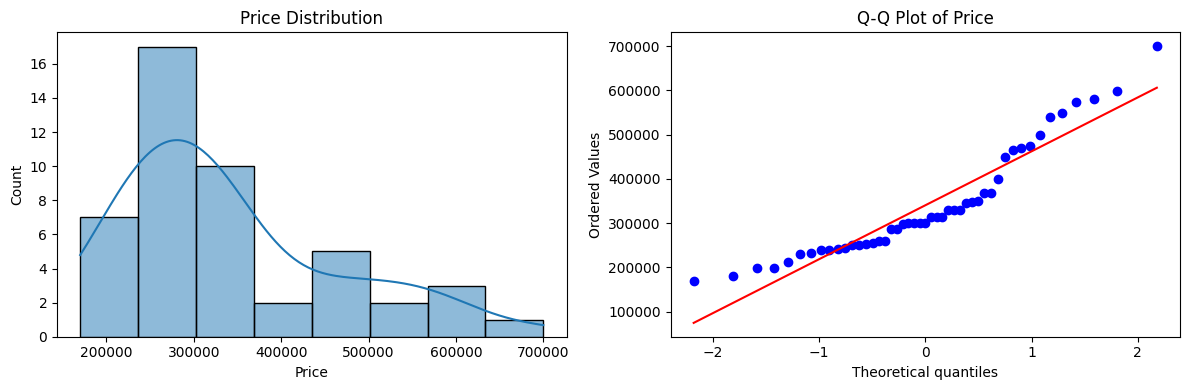

Skewness: 1.06


In [ ]:
# Step 2: Target Variable (Price) Distribution – Check for Skewness
# Linear regression loves normally distributed residuals. 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

# Q-Q Plot (Quantile-Quantile) to check normality
stats.probplot(df['Price'], dist="norm", plot=axes[1])
# probplot function retunrs array, add plot to plot it
axes[1].set_title('Q-Q Plot of Price')

plt.tight_layout()
plt.show()

# Skewness metric
print(f"Skewness: {df['Price'].skew():.2f}")

# Observations:

# If skewness is > 0.5, the data is right-skewed (long tail towards high prices).

# If the Q-Q plot deviates from the red line, it's not perfectly normal.

# Action: If skewed, we will later apply a log transformation 
# (np.log(Price)) to make it more Gaussian, which usually improves linear regression performance.

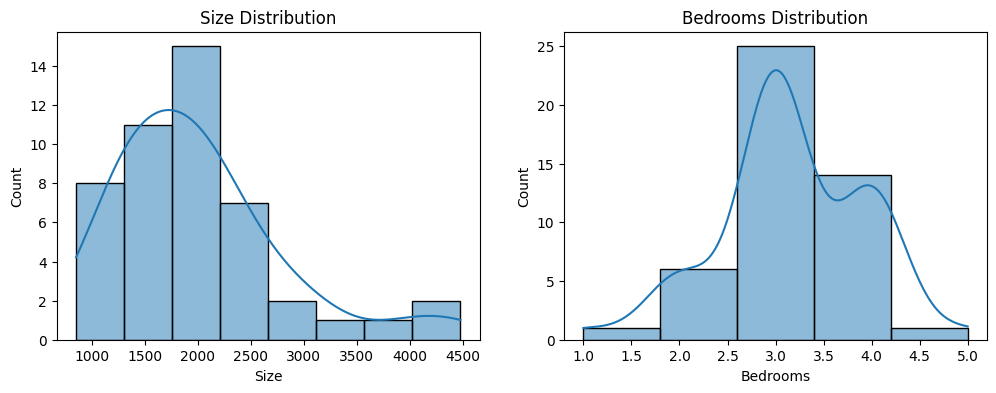

In [ ]:
#Step 3: Feature Analysis (Univariate)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Size'], kde=True, ax=axes[0])
axes[0].set_title('Size Distribution')

sns.histplot(df['Bedrooms'], kde=True, ax=axes[1], bins=5) # Discrete variable
axes[1].set_title('Bedrooms Distribution')

plt.show()

# Observations:
# Size is relatively smooth, maybe a slight right skew.
# Bedrooms is discrete (1 to 5). Linear regression can handle discrete numeric features, but just note that it's not continuous.

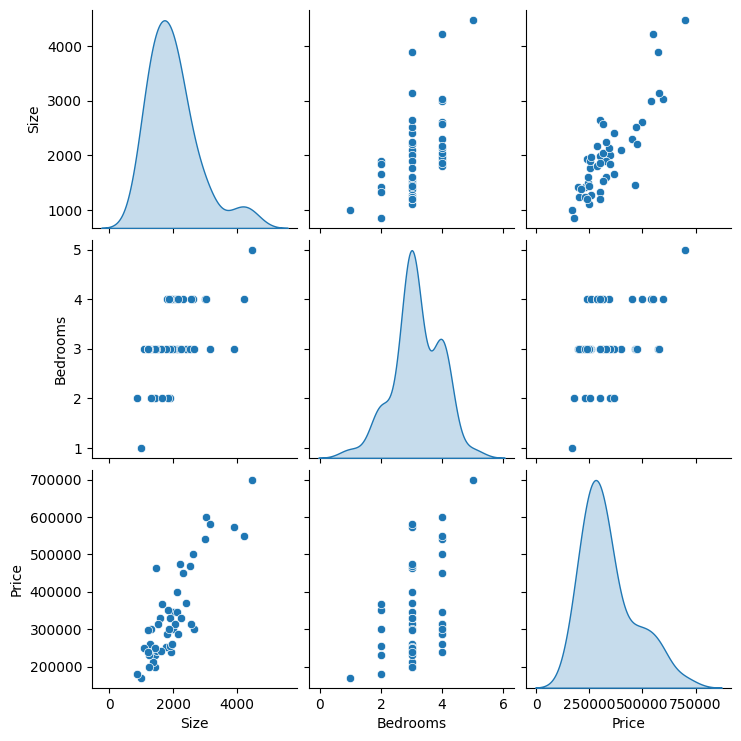

In [ ]:
# Step 4: Bivariate Analysis – The "Linearity" Check (CRITICAL)
#For linear regression, each feature and the target ~ roughly linear.
sns.pairplot(df, diag_kind='kde')
plt.show()

# SNS PARIPLOT WITH SECTORS
# sns.pairplot(df, hue='Price', diag_kind='kde')
# plt.show()

# PANDAS VERSION
# pd.plotting.scatter_matrix(df, alpha=0.8, figsize=(10, 10), diagonal='kde')
# plt.show()

# No matrix 
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# # Size vs Price
# sns.scatterplot(x='Size', y='Price', data=df, ax=axes[0])
# axes[0].set_title('Size vs Price')
# # Bedrooms vs Price
# sns.scatterplot(x='Bedrooms', y='Price', data=df, ax=axes[1])
# axes[1].set_title('Bedrooms vs Price')
# plt.tight_layout()
# plt.show()

Interpretation:

    Size vs Price: Clear, strong, positive linear relationship. This will be our star predictor.

    Bedrooms vs Price: Look closely – the relationship is messy. For 3-bedroom houses, prices vary wildly (from ~200k to ~600k). This tells us that Bedrooms alone is a weak predictor.

    Important: Notice that houses with 5 bedrooms are only the ones with massive Size. This hints at multicollinearity (bigger houses naturally have more bedrooms).